In [1]:
%load_ext autoreload
%autoreload
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import h5py
import numpy as np
import importlib

filepath = '/Volumes/Elements/Boesky_alpha0.1beta0.5.h5'
fdata = h5py.File(filepath)
all_dco_seeds = fdata['BSE_Double_Compact_Objects']['SEED'][()]
all_seeds = fdata['BSE_System_Parameters']['SEED'][()]
metallicities = fdata["BSE_System_Parameters"]["Metallicity@ZAMS(1)"][()]
# potentially mask with/without a stable mass transfer or without an envelope
mixture_weight = fdata["BSE_System_Parameters"]["mixture_weight"][()]
TYPES = 'BBH'
# rates_key = f'Rates_mu00.025_muz-0.052_alpha-1.88_sigma01.15_sigmaz0.0477_{TYPES}_0.1_10.0'
rates_key = f'Rates_{TYPES}_mixed'
dcomask = fdata[rates_key]['DCOmask']
dco_query = np.isin(all_seeds, all_dco_seeds[dcomask])
dco_metallicities = metallicities[dco_query]

assert len(dco_metallicities) == np.sum(dcomask), "DCO masking failure"

In [2]:
import shared
importlib.reload(shared)
plotting_data = shared.fci_plot_merger_rate_from_hdf_file(filepath, rates_key, dco_metallicities)

38


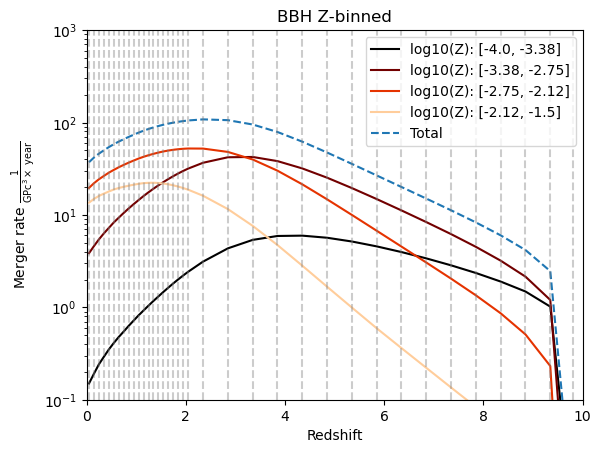

In [4]:
merger_fig, merger_ax = plt.subplots(1, 1)
# merger_ax.set_ylim(np.min(merger_ax_rates), np.max(merger_ax_rates))
merger_ax.yaxis.set_inverted(False)  # ensure not inverted

# restore auto ticks/labels
merger_ax.yaxis.set_major_locator(mticker.AutoLocator()) #from GPT. something was wrong with matplotlib
merger_ax.yaxis.set_major_formatter(mticker.ScalarFormatter())

color_bins = plt.cm.gist_heat(np.linspace(0, 0.9, plotting_data['merger_rates_binned_by_metallicities'].shape[0]-1))
red_centers = (plotting_data['redshifts'][:-1] + plotting_data['redshifts'][1:])/2

for bi in range(plotting_data['merger_rates_binned_by_metallicities'].shape[0]-1):     
    merger_ax.plot(
        # np.round(plotting_data['redshifts'],2),
        red_centers,
        plotting_data['merger_rates_binned_by_metallicities'][bi][:-1],
        color=color_bins[bi],
        label=f'log10(Z): [{plotting_data['merger_metallicity_bins'][bi]}, {plotting_data['merger_metallicity_bins'][bi+1]}]'
    )

# merger_ax.plot(
#     red_centers,
#     np.sum(fdata[rates_key]['merger_rate'], axis=0),
#     label='FCI MR'
# )
# print(plotting_data['merger_rates_binned_by_metallicities'].shape)
merger_ax.plot(
    red_centers,
    np.sum(plotting_data['merger_rates_binned_by_metallicities'],axis=0)[:-1],
    label='Total',
    linestyle='dashed'
)

for r in red_centers:
    merger_ax.axvline(r, color='grey', linestyle='dashed', alpha=0.4)

merger_ax.set_xlabel('Redshift')
merger_ax.set_yscale('log')

merger_ax.set_ylabel(r'Merger rate $\frac{1}{\text{GPc}^3\times~\text{year}}$')
merger_ax.legend()
merger_ax.set_title(f'{TYPES} Z-binned')

merger_ax.set_xlim(0, 10)
merger_ax.set_ylim(1e-1,1e3)
merger_fig.savefig('fci_merger_rates.png')
